# Visual Steganography: Least Significant Bit (LSB) Method

This project demonstrates how to hide a full-resolution image inside another image without significantly altering its visual appearance.

**The Logic:**
Digital images are made of pixels represented by 8 bits (values 0-255).
1.  **Most Significant Bits (MSB):** The first 6 bits contain the main visual information (color/brightness).
2.  **Least Significant Bits (LSB):** The last 2 bits contain fine details that are less noticeable to the human eye.

We will replace the **LSB** of a "Cover Image" with the **MSB** of a "Secret Image".

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

# Configure plot size and color map
plt.rcParams['figure.figsize'] = [15, 8]
plt.rcParams['image.cmap'] = 'gray'

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Step 2: Load and Prepare Images

We load two images:
1.  **Cover Image:** The visible container (e.g., a city landscape).
2.  **Secret Image:** The hidden payload (e.g., a high-contrast symbol).

**Crucial Step:** We resize the Secret Image to match the exact dimensions (Width x Height) of the Cover Image so the pixel matrices align perfectly.

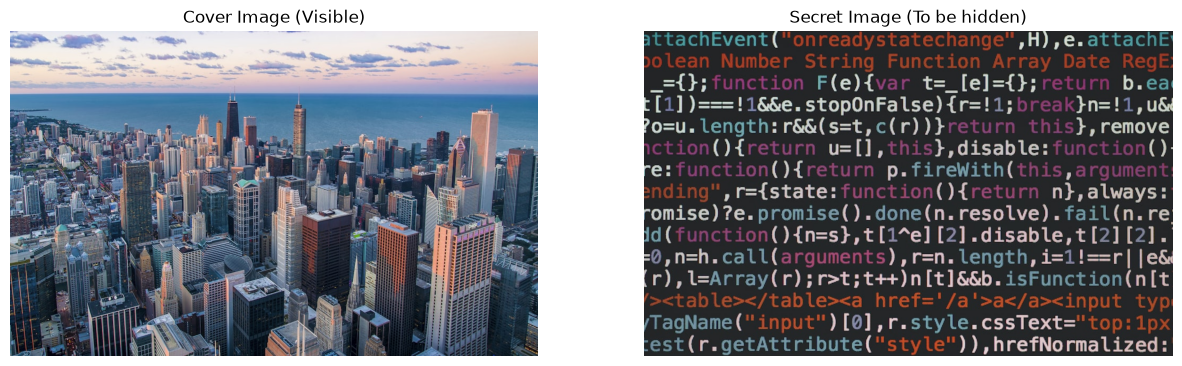

Images ready. Dimensions: (615, 1000, 3)


In [2]:
def load_image_from_url(url):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert('RGB')
    return np.array(img)

# 1. Load the Cover Image (The visible one)
url_cover = "https://images.unsplash.com/photo-1477959858617-67f85cf4f1df?ixlib=rb-4.0.3&auto=format&fit=crop&w=1000&q=80"
img_cover = load_image_from_url(url_cover)

# 2. Load the Secret Image (The hidden one)
url_secret = "https://images.unsplash.com/photo-1516259762381-22954d7d3ad2?ixlib=rb-4.0.3&auto=format&fit=crop&w=1000&q=80"
img_secret_raw = load_image_from_url(url_secret)

# 3. Resize Secret Image to match Cover Image dimensions
height, width, channels = img_cover.shape
img_secret = np.array(Image.fromarray(img_secret_raw).resize((width, height)))

# Display the source images
fig, ax = plt.subplots(1, 2)
ax[0].imshow(img_cover)
ax[0].set_title("Cover Image (Visible)")
ax[0].axis('off')

ax[1].imshow(img_secret)
ax[1].set_title("Secret Image (To be hidden)")
ax[1].axis('off')

plt.show()

print(f"Images ready. Dimensions: {img_cover.shape}")

## Step 3: Define Steganography Logic (Stealth Mode)

We define the functions to merge the images.
To avoid "ghosting" artifacts in the visible image, we will use a **2-bit injection strategy**:

* **Cover Image:** We keep the top 6 bits (99% of visual fidelity).
* **Secret Image:** We compress it into the 2 least significant bits.

**Trade-off:** The cover image will look perfect (stealth), but the recovered secret image will have lower color depth.

In [3]:
def hide_image(img_visible, img_hidden, bits=2):
    """
    Hides 'bits' amount of data from hidden image into visible image.
    bits=2 is recommended for perfect invisibility.
    """
    # 1. Prepare the mask to KEEP the upper bits of the cover
    # If bits=2, mask is 11111100 (0xFC)
    keep_mask = (0xFF << bits) & 0xFF 
    visible_clean = img_visible & keep_mask
    
    # 2. Prepare the mask to TAKE the upper bits of the secret
    # If bits=2, shift is 6. We take top 2 bits and move them to bottom.
    shift = 8 - bits
    erase_mask = (0xFF << shift) & 0xFF
    hidden_shrunk = (img_hidden & erase_mask) >> shift
    
    # 3. Merge
    return visible_clean | hidden_shrunk

def reveal_image(stego_image, bits=2):
    """
    Extracts the hidden bits and restores them to visible range.
    """
    shift = 8 - bits
    
    # 1. Isolate the hidden bits (bottom 2 bits)
    mask = (1 << bits) - 1 
    hidden_data = stego_image & mask
    
    # 2. Shift them to the top to make them visible
    return hidden_data << shift

print(f"Functions defined. Stealth Protocol ready.")

Functions defined. Stealth Protocol ready.


## Step 4: Execute and Visualize

We run the process using **2 bits** for maximum stealth.

**Visual Analysis:**
1.  **Stego Image:** Should look identical to the original Cover. No visible ghosts.
2.  **Noise/Difference:** We amplify the difference **x50**. If you see noise here, it means the data is successfully embedded, even if you can't see it in the first image.
3.  **Extracted Secret:** The recovered image. It will have lower quality (posterized) due to the 2-bit compression, but should be clearly legible.

Running Steganography with 2-bit depth...


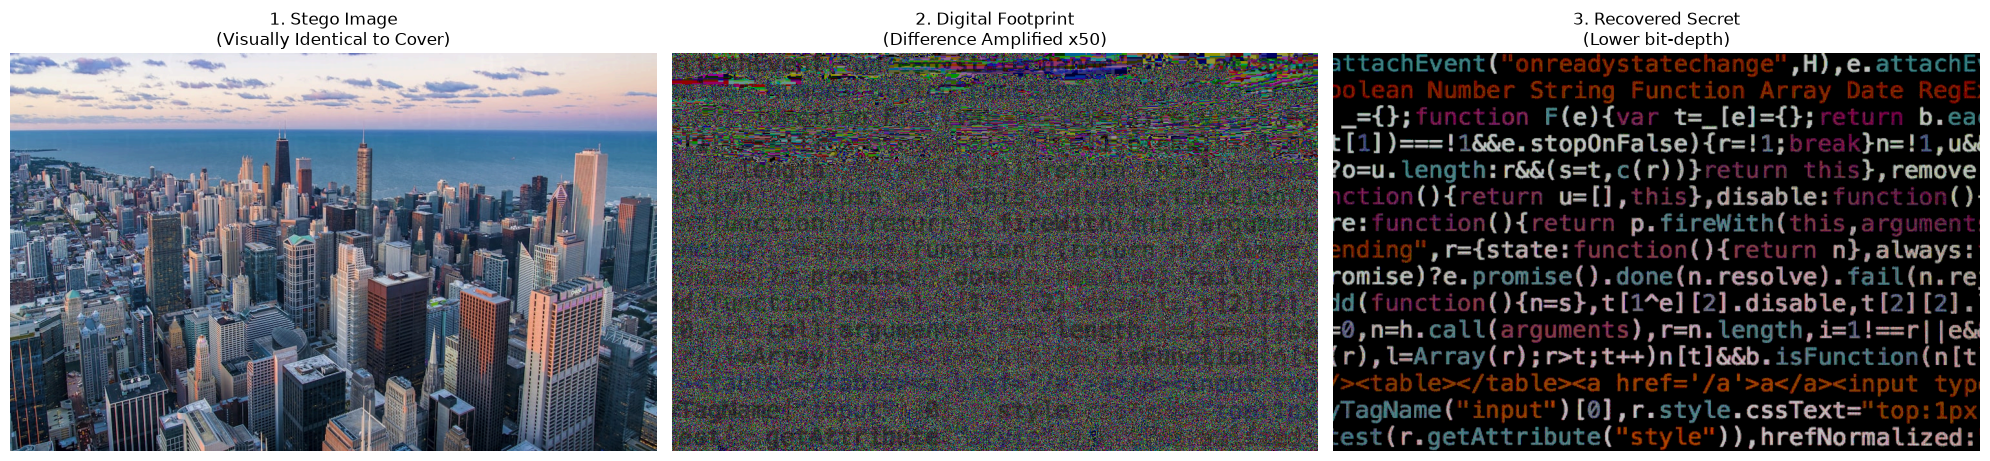

In [4]:
STEALTH_BITS = 2  # 2 bits = Invisible.

print(f"Running Steganography with {STEALTH_BITS}-bit depth...")

# 1. ENCRYPT
stego_image = hide_image(img_cover, img_secret, STEALTH_BITS)

# 2. DECRYPT
extracted_image = reveal_image(stego_image, STEALTH_BITS)

# --- VISUAL VERIFICATION ---
plt.figure(figsize=(20, 8))

# Panel 1: The Result (Cover + Secret)
plt.subplot(1, 3, 1)
plt.imshow(stego_image)
plt.title("1. Stego Image\n(Visually Identical to Cover)")
plt.axis('off')

# Panel 2: The Proof (Difference)
# We subtract the original from the result.
diff = np.abs(stego_image.astype(int) - img_cover.astype(int))
# Multiply by 50 to make the tiny 2-bit changes visible in the plot
plt.subplot(1, 3, 2)
plt.imshow(diff * 50) 
plt.title("2. Digital Footprint\n(Difference Amplified x50)")
plt.axis('off')

# Panel 3: The Secret
plt.subplot(1, 3, 3)
plt.imshow(extracted_image)
plt.title("3. Recovered Secret\n(Lower bit-depth)")
plt.axis('off')

plt.tight_layout()
plt.show()

## Step 5: Save Result

We save the resulting image to the disk.

**Important:** We must use **PNG format**. If we used JPG, the compression algorithm would treat our hidden bits as "unnecessary noise" and delete them, destroying the secret message.

In [5]:
output_filename = "stego_image_result.png"

# Convert the numpy array back to a PIL Image object
result_pil = Image.fromarray(stego_image)

# Save as PNG (Lossless)
result_pil.save(output_filename)

print(f"Success! Image saved as '{output_filename}'.")
print("You can send this PNG to a friend, and they can use the 'reveal_image' function to see the secret.")

Success! Image saved as 'stego_image_result.png'.
You can send this PNG to a friend, and they can use the 'reveal_image' function to see the secret.
